# Physics-based battery modelling with PyBaMM

Python Battery Mathematical Modelling (PyBaMM) is an open-source software package for physics-based modelling of Li-ion batteries. This notebook will help to demonstrate some of the physical processes happening inside a cell. We will subject a virtual battery to conditions similar to the parameterisation data and drive cycle supplied in this project.

First, install and import PyBaMM and other Python libraries we may need.

In [3]:
# %pip install pybamm -q    # install PyBaMM if it is not installed
import pybamm
%matplotlib inline

PyBaMM can run a range of physics-based models. The pseudo-2D model, also known as the Doyle-Fuller-Newman model after its inventors, was published in 1993 and has been widely used ever since.

In [4]:
model = pybamm.lithium_ion.DFN()

The DFN model requires many input parameters. We are going to use the parameters from O'Kane et al. (2022), which were also for a cylindrical cell. Load these parameters but allow the temperature to be varied by the user.

In [5]:
param = pybamm.ParameterValues("OKane2022")
# param["Ambient temperature [K]"] = pybamm.InputParameter("T")
param

{'Ambient temperature [K]': 298.15,
 'Bulk solvent concentration [mol.m-3]': 2636.0,
 'Cation transference number': 0.2594,
 'Cell cooling surface area [m2]': 0.00531,
 'Cell thermal expansion coefficient [m.K-1]': 1.1e-06,
 'Cell volume [m3]': 2.42e-05,
 'Contact resistance [Ohm]': 0,
 'Current function [A]': 5.0,
 'Dead lithium decay constant [s-1]': 1e-06,
 'Dead lithium decay rate [s-1]': <function SEI_limited_dead_lithium_OKane2022 at 0x12f23c7c0>,
 'EC diffusivity [m2.s-1]': 2e-18,
 'EC initial concentration in electrolyte [mol.m-3]': 4541.0,
 'Electrode height [m]': 0.065,
 'Electrode width [m]': 1.58,
 'Electrolyte conductivity [S.m-1]': <function electrolyte_conductivity_Nyman2008_arrhenius at 0x12f23cea0>,
 'Electrolyte diffusivity [m2.s-1]': <function electrolyte_diffusivity_Nyman2008_arrhenius at 0x12f23ce00>,
 'Exchange-current density for plating [A.m-2]': <function plating_exchange_current_density_OKane2020 at 0x12f23c680>,
 'Exchange-current density for stripping [A.m-2

We will use the Experiment class to define the simulation conditions.

In [6]:
exp = pybamm.Experiment([
    "Rest for 10 seconds (0.1s period)",
    "Discharge at 2C for 1 minutes (0.1s period)",
    "Rest for 2 minutes (0.1s period)",
], temperature=298.15)

Specify the mesh. Many problems in PyBaMM can be solved by increasing r_n or r_p.

In [7]:
var_pts = {
    "x_n": 40, # electrode cells
    "x_s": 40, # electrolyte
    "x_p": 40, # electrode
    "r_n": 40, # cells inside sphere
    "r_p": 40, # cells inside sphere
}

Create a Simulation class using the model, parameter values, Experiment and mesh defined earlier, then solve it!

In [8]:
sim = pybamm.Simulation(model=model, parameter_values=param, experiment=exp, var_pts=var_pts)
sol = sim.solve()

Figure 1: Plot the components that make up the voltage drop during the pulse.

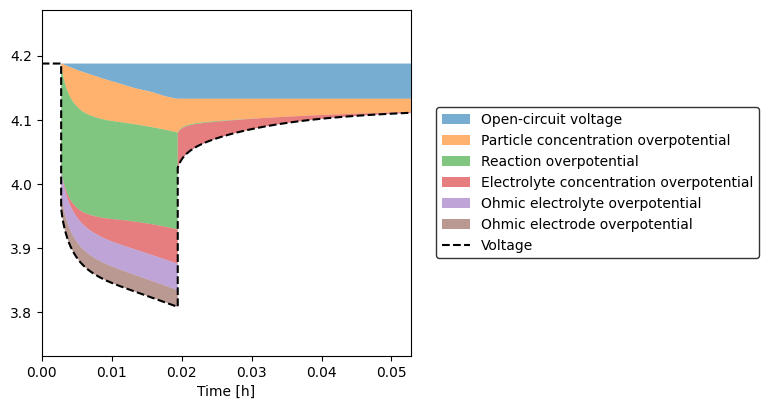

In [9]:
pl = pybamm.plot_voltage_components(sol)

Figure 2: plot the concentrations of lithium inside the cell. $x$ is the axis between the negative and positive current collectors. $r$ is the radial position in the electrode particles. Drag the slider to see the distribution of lithium at different times during the pulse.

In [ ]:
output_variables = [
        "Negative particle concentration [mol.m-3]",
        "Electrolyte concentration [mol.m-3]",
        "Positive particle concentration [mol.m-3]",
        "Current [A]",
        "Voltage [V]",
    ]
quick_plot = pybamm.QuickPlot(
    sol,output_variables,variable_limits='fixed',   # variable_limits='tight',
    time_unit='hours',n_rows=2) #figsize = (18,12),

fig = quick_plot.dynamic_plot()